# 超强总结！十大数据预处理技巧！！  
https://mp.weixin.qq.com/s/UZLox9Kqo0m6h2SuLwZvMg

**（注：本文Markdown格式由大语言模型整理转移，公式有许多自行正确理解且与原文差异较大的情况，仅完成了部分检查和改正一致）**

其实做机器学习，最花时间的不是训练模型，而是整理数据。模型好不好，很大程度上取决于你前期怎么处理数据。很多时候我们80%的精力都花在清洗、规范、补全这些看起来“琐碎”的步骤上。你数据处理得越干净，后面建模就越轻松，效果也更稳。

说白了，**数据预处理**就像盖房子打地基，地基不牢，很难搭高楼。

涉及到的十个数据预处理的方法：
- 数据清洗
- 数据标准化
- 数据编码
- 特征选择
- 特征缩放
- 降维
- 数据拆分
- 数据增强
- 数据平衡
- 数据转换

通过理论和案例，详细和大家聊聊~

### 1. 数据清洗 (Data Cleaning)

#### 1.1 处理缺失值 (Handling Missing Values)
**原理**  
数据缺失可能由于采集不全或错误输入等原因。在机器学习中，处理缺失值可以避免模型的偏差。

**方法与公式**  
- **均值填充 (Mean Imputation)**  
  对于缺失值$x_i$，用相应特征的均值$\mu$代替：  
  $x_i=\mu=\frac{1}{N}\sum\limits_{i=1}^N x_i$  
  均值是数据集中值的最优估计（最小二乘估计），它使误差平方和最小化。

- **插值法 (Interpolation)**  
  线性插值：假设$x_i$在$x_{i-1}$和$x_{i+1}$之间缺失，可以通过线性插值估计：  
  $x_i=\frac{x_i-1+x_{i+1}}{2}$  
  推导：线性插值假设数据在缺失点附近变化线性，误差函数为：  
  $E=(x_i-x_{i-1})^2+(x_i-x_{i+1})^2$  
  通过对求导并设导数为零，得到：  
  $\frac{\partial E}{\partial x_i}=2(x_i-x_{i-1})+2(x_i-x_{i+1})=0$   
  解得：  
  $x_i=\frac{x_i-1+x_{i+1}}{2}$ 

#### 1.2 处理异常值 (Handling Outliers)
**原理**  
异常值是偏离正常数据分布的值，可能由于数据录入错误或实际存在的异常情况引起。

**方法与公式**  
- **Z-Score (标准分数法)**  
  异常值通过Z-Score判断，Z-Score定义为：  
  $z=\frac{x_i-\mu}{\sigma}$   
  推导：  
  对于标准正态分布，均值为0，标准差为1。通过减去均值并除以标准差，将原数据标准化为标准正态分布。  
  Z-Score反映了数据点离均值的标准差数。通常，|z| > 3 被认为是异常值，因为在正态分布中，99.7%的数据落在$|-3\sigma,+3\sigma|$（±3个标准差）之间。

- **IQR (Interquartile Range, 四分位距)**  
  IQR定义为数据集的第三四分位数Q3与第一四分位数Q1之差：  
  IQR = Q3 - Q1    
  数据点小于Q1 - 1.5×IQR 或大于 Q3 + 1.5×IQR 时，视为异常值。    
  推导：  
  四分位数Q1和Q3分别是数据排序后25%和75%处的数值。IQR捕捉了数据集中间50%的分布范围。  
  设定1.5倍的IQR作为界限是经验法则，用来捕捉明显的异常值。

- **Python案例**  
假设我们有一个数据集，记录了不同地区的房屋价格、面积、卧室数量以及房屋建造年份。数据集中存在一些缺失值和异常值，需要通过数据清洗进行处理。最后，我们将对数据进行标准化并展示数据分布的变化。



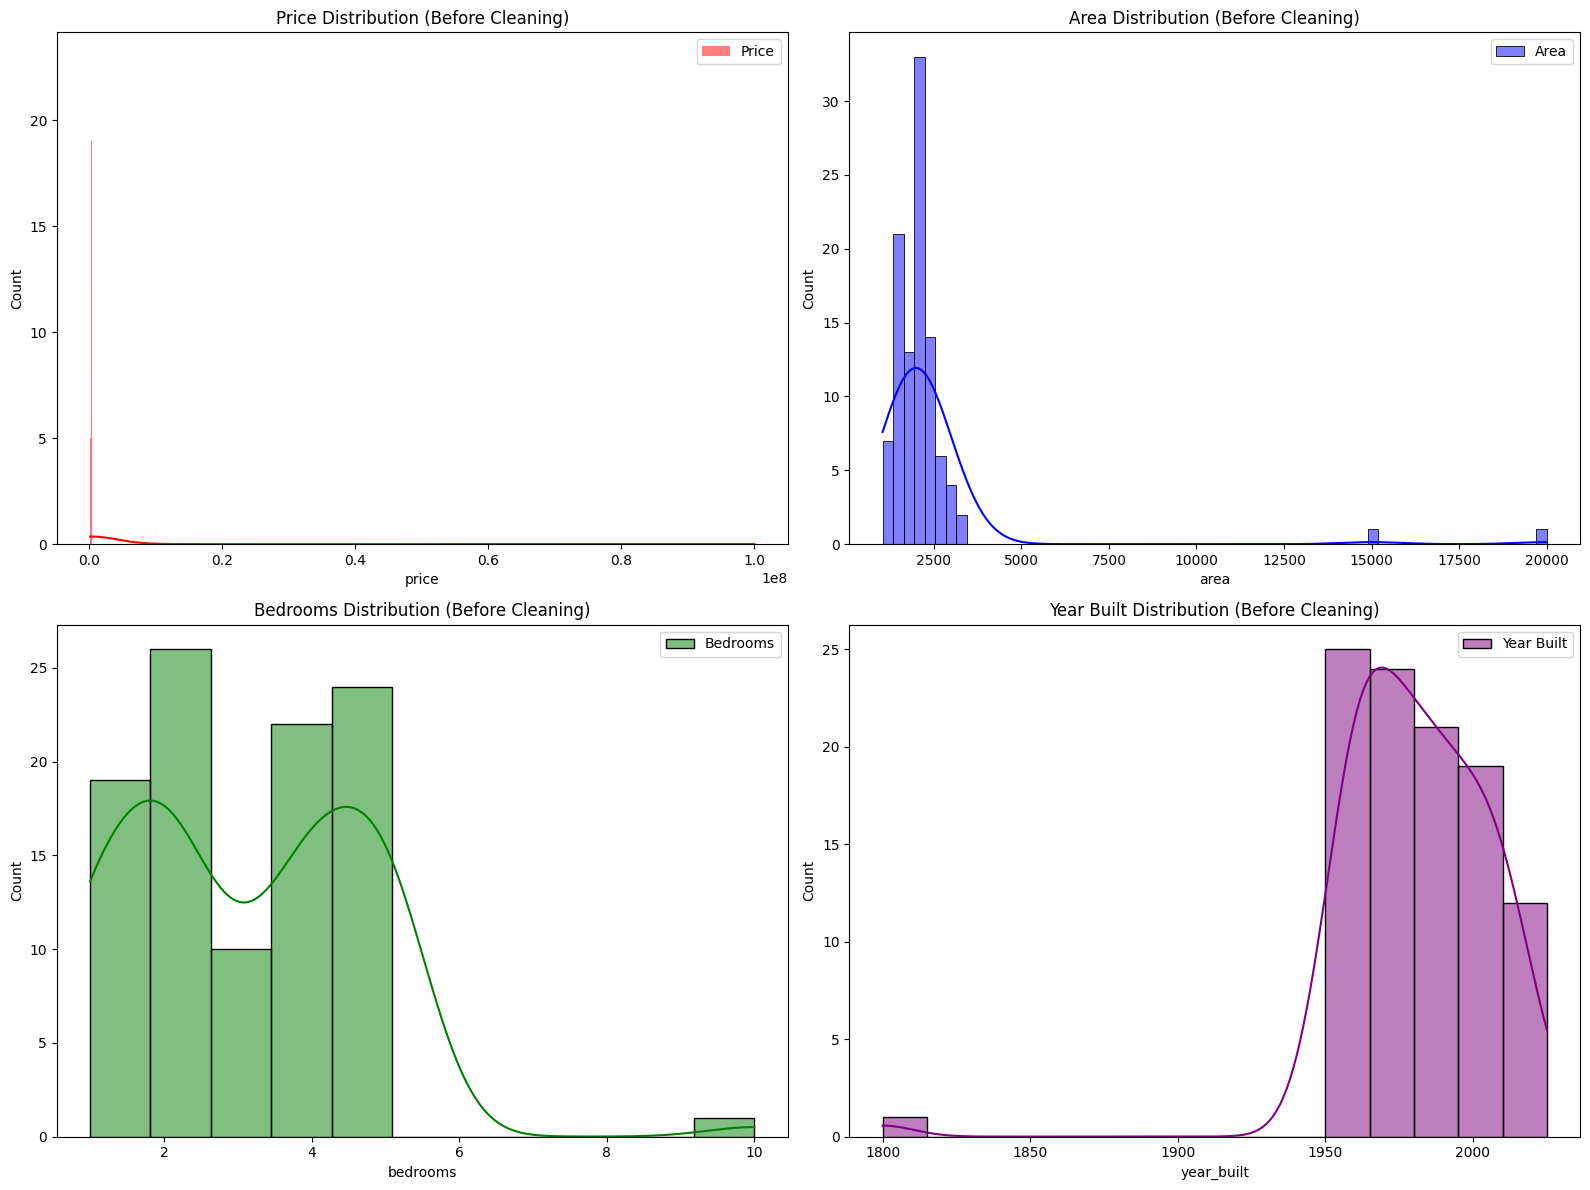

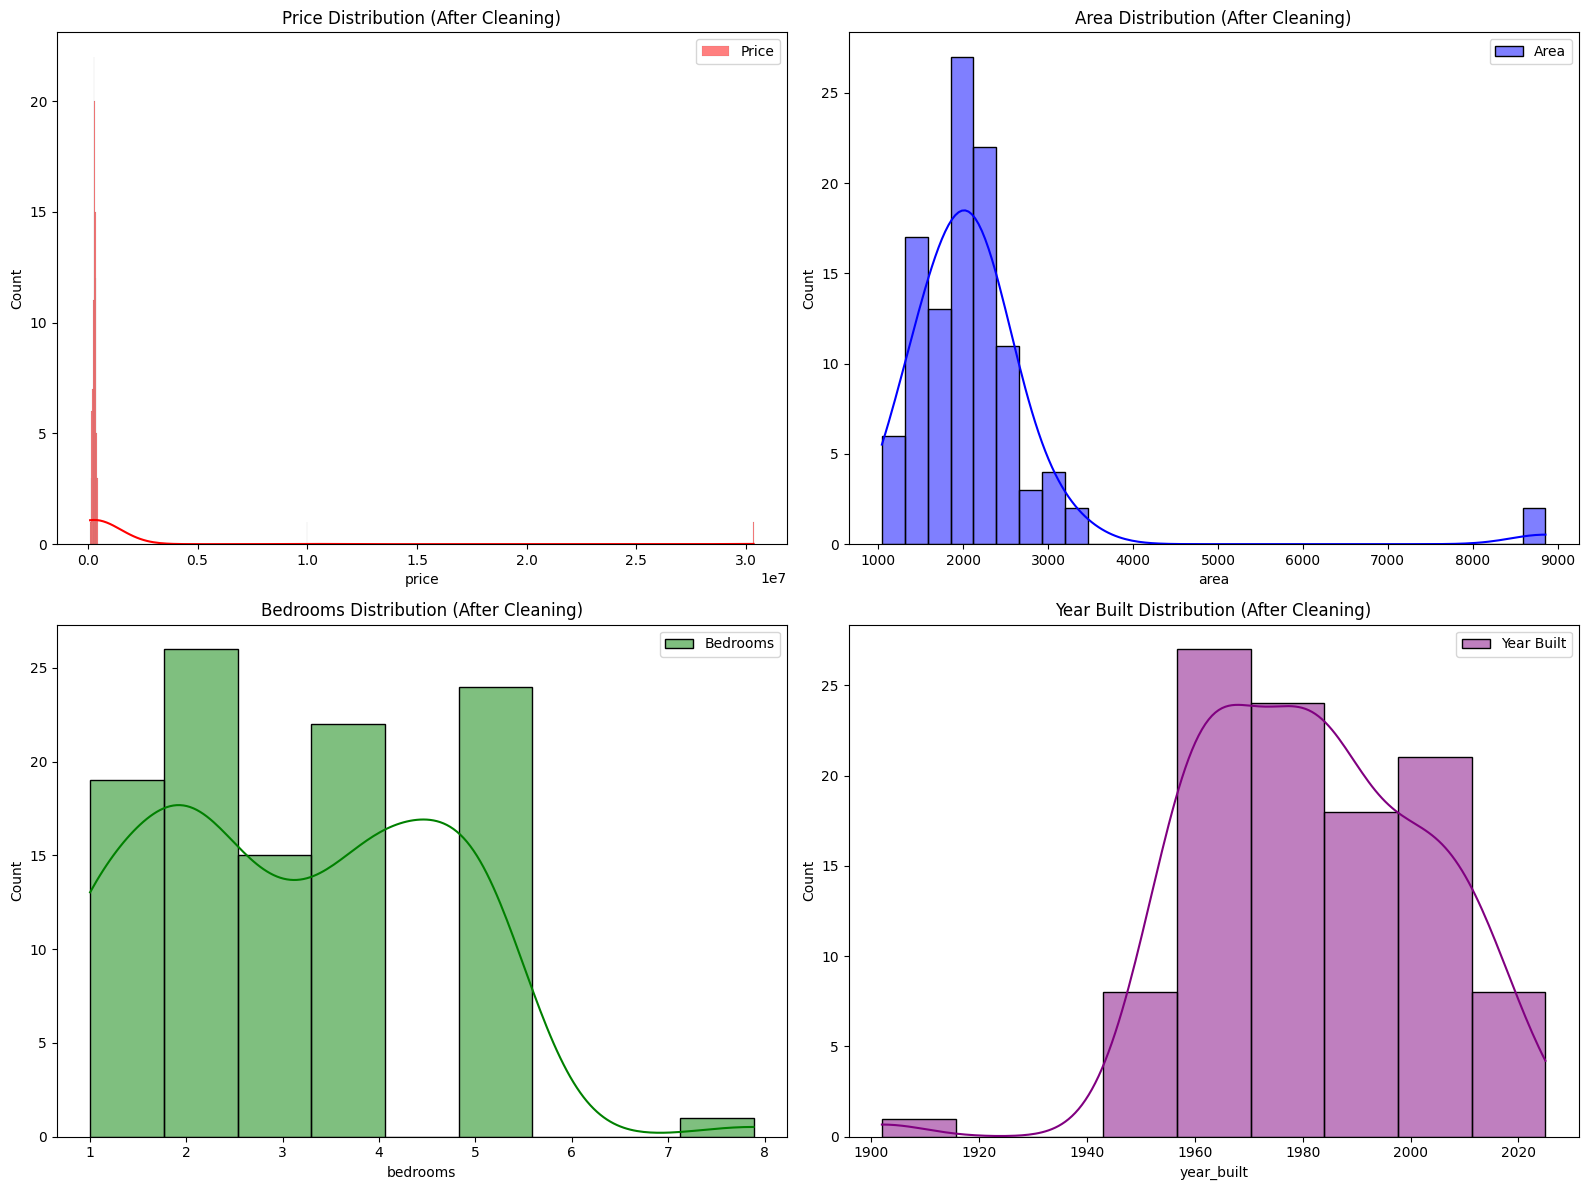

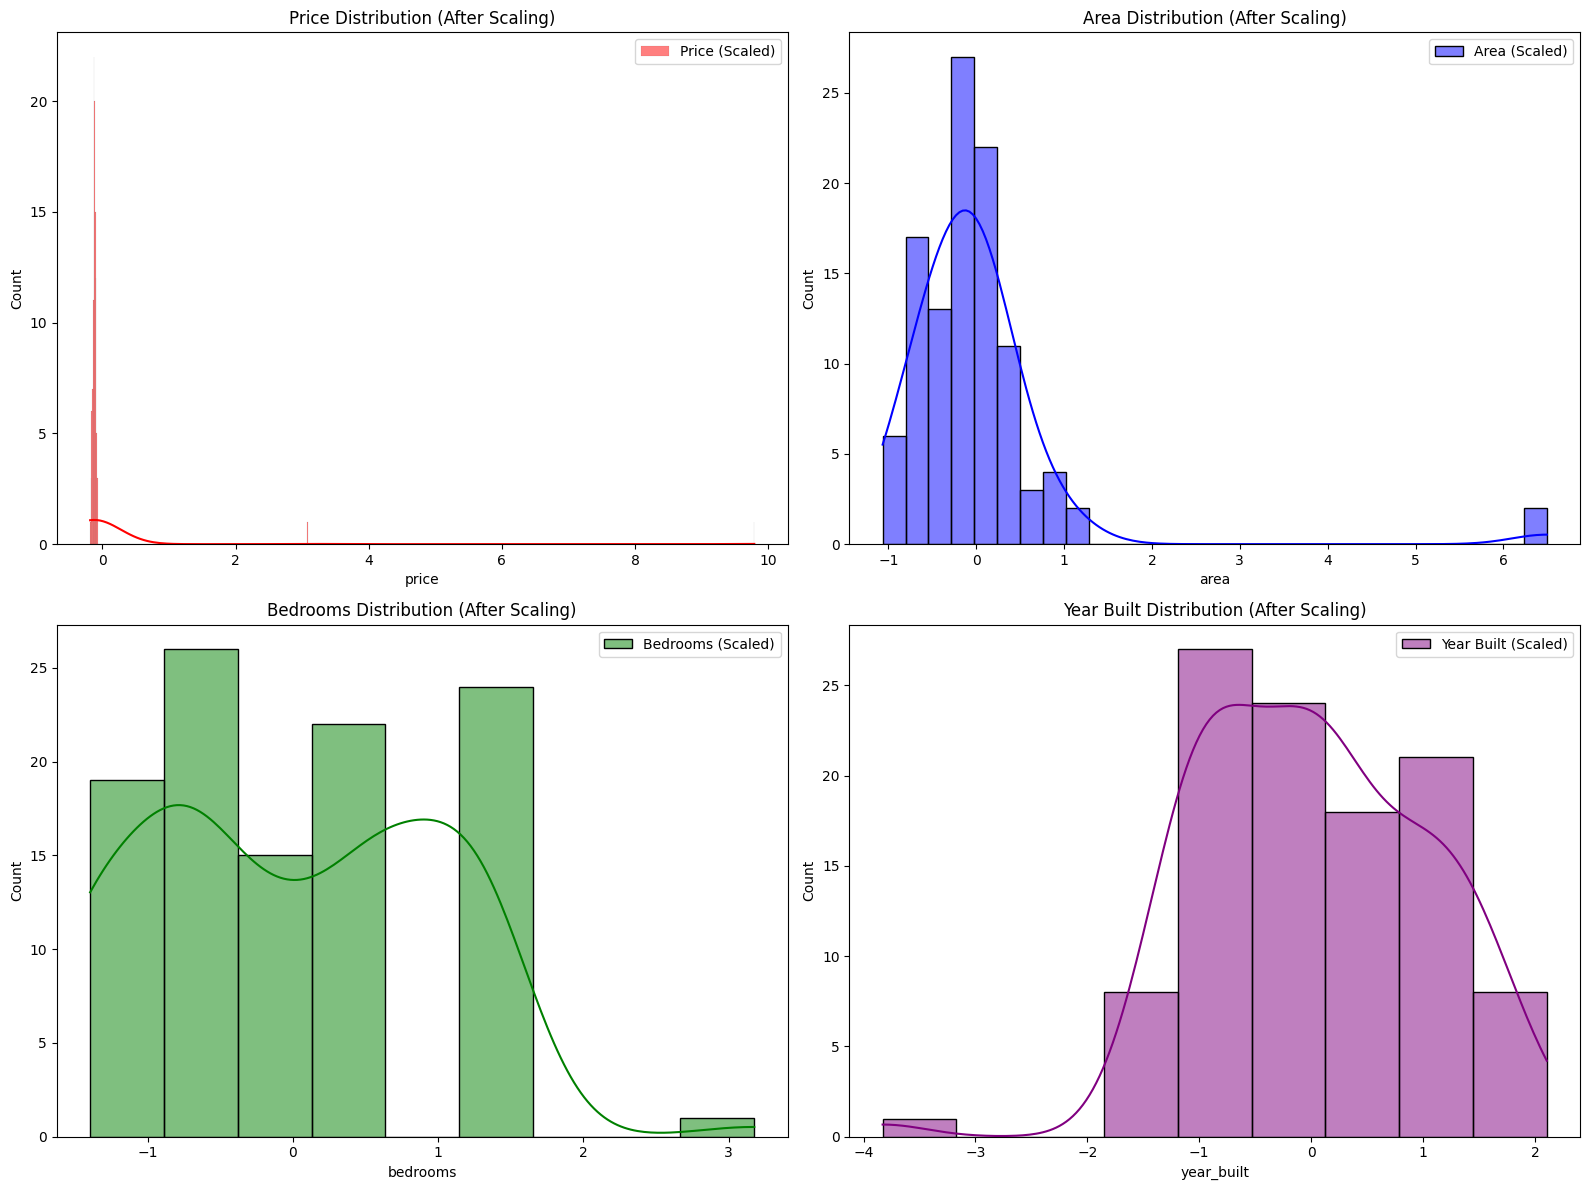

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 设置随机种子
np.random.seed(42)

# 生成虚拟数据集
data = {
    'price': np.random.normal(300000, 75000, 100).tolist() + [np.nan]*5 + [1e7, 1e8],  # 房屋价格，包含缺失值和异常值
    'area': np.random.normal(2000, 500, 100).tolist() + [np.nan]*5 + [15000, 20000],   # 房屋面积，包含缺失值和异常值
    'bedrooms': np.random.randint(1, 6, 100).tolist() + [np.nan]*5 + [1, 10],          # 卧室数量，包含缺失值和异常值
    'year_built': np.random.randint(1950, 2020, 100).tolist() + [np.nan]*5 + [1800, 2025]  # 建造年份，包含缺失值和异常值
}

df = pd.DataFrame(data)

# 绘制数据清洗前的分布图
plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
sns.histplot(df['price'], kde=True, color='red', label='Price')
plt.title('Price Distribution (Before Cleaning)')
plt.legend()

plt.subplot(2, 2, 2)
sns.histplot(df['area'], kde=True, color='blue', label='Area')
plt.title('Area Distribution (Before Cleaning)')
plt.legend()

plt.subplot(2, 2, 3)
sns.histplot(df['bedrooms'], kde=True, color='green', label='Bedrooms')
plt.title('Bedrooms Distribution (Before Cleaning)')
plt.legend()

plt.subplot(2, 2, 4)
sns.histplot(df['year_built'], kde=True, color='purple', label='Year Built')
plt.title('Year Built Distribution (Before Cleaning)')
plt.legend()

plt.tight_layout()
plt.show()

# 数据清洗步骤

# 1. 处理缺失值：使用中位数填充缺失值
df.fillna(df.median(), inplace=True)

# 2. 处理异常值：将超过三倍标准差的值视为异常值并替换为上下限
for col in df.columns:
    upper_limit = df[col].mean() + 3 * df[col].std()
    lower_limit = df[col].mean() - 3 * df[col].std()
    df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])
    df[col] = np.where(df[col] < lower_limit, lower_limit, df[col])

# 3. 数据标准化
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# 绘制数据清洗后的分布图
plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
sns.histplot(df['price'], kde=True, color='red', label='Price')
plt.title('Price Distribution (After Cleaning)')
plt.legend()

plt.subplot(2, 2, 2)
sns.histplot(df['area'], kde=True, color='blue', label='Area')
plt.title('Area Distribution (After Cleaning)')
plt.legend()

plt.subplot(2, 2, 3)
sns.histplot(df['bedrooms'], kde=True, color='green', label='Bedrooms')
plt.title('Bedrooms Distribution (After Cleaning)')
plt.legend()

plt.subplot(2, 2, 4)
sns.histplot(df['year_built'], kde=True, color='purple', label='Year Built')
plt.title('Year Built Distribution (After Cleaning)')
plt.legend()

plt.tight_layout()
plt.show()

# 绘制标准化后的数据分布图
plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
sns.histplot(df_scaled['price'], kde=True, color='red', label='Price (Scaled)')
plt.title('Price Distribution (After Scaling)')
plt.legend()

plt.subplot(2, 2, 2)
sns.histplot(df_scaled['area'], kde=True, color='blue', label='Area (Scaled)')
plt.title('Area Distribution (After Scaling)')
plt.legend()

plt.subplot(2, 2, 3)
sns.histplot(df_scaled['bedrooms'], kde=True, color='green', label='Bedrooms (Scaled)')
plt.title('Bedrooms Distribution (After Scaling)')
plt.legend()

plt.subplot(2, 2, 4)
sns.histplot(df_scaled['year_built'], kde=True, color='purple', label='Year Built (Scaled)')
plt.title('Year Built Distribution (After Scaling)')
plt.legend()

plt.tight_layout()
plt.show()

1. 数据生成：我们创建了一个包含房屋价格、面积、卧室数量和建造年份的虚拟数据集。数据中故意加入了一些缺失值和异常值。  
2. 绘制原始数据的分布：使用 seaborn 绘制原始数据的分布图，以展示数据在清洗前的状态。  
3. 数据清洗：  
- 缺失值处理：用各列的中位数填充缺失值。
- 异常值处理：用均值±3倍标准差范围以外的值作为异常值，并替换为上下限。
4. 数据标准化：使用 StandardScaler 对数据进行标准化，以便将不同特征的值缩放到相同的尺度。


### 2. 数据标准化 (Normalization)

#### 2.1 归一化 (Min-Max Scaling)
**原理**  
归一化将数据缩放到指定范围（通常为[0, 1]或[-1, 1]），使得不同特征在同一量纲下进行比较，适合特征值差异较大的情况。

**公式**  
$x' = \frac{x - \min(x)}{\max(x) - \min(x)}$  

**推导**  
假设原始数据的最小值为$\min(x)$，最大值为$\max(x)$，则将数据线性缩放到[0, 1]范围内的目标是：$x' = a \cdot x + b$  
其中，缩放系数$a$和偏移量$b$需要满足：  
$\max(x') = 1 = a \cdot \max(x) + b$  
$\min(x') = 0 = a \cdot \min(x) + b$  
解得：$a = \frac{1}{\max(x) - \min(x)}$，$b = -\frac{\min(x)}{\max(x) - \min(x)}$  
代入到原公式中，得到：$x' = \frac{x - \min(x)}{\max(x) - \min(x)}$

#### 2.2 标准化 (Z-Score Normalization)
**原理**  
标准化将数据变换为均值为0、标准差为1的标准正态分布形式，用以消除不同特征之间的量纲差异。

**公式**  
$x' = \frac{x - \mu}{\sigma}$  
其中，$\mu$是数据的均值，$\sigma$是数据的标准差。

**推导**  
假设数据$x$的均值为$\mu$，标准差为$\sigma$，则对数据进行标准化的目的是将其转化为标准正态分布$N(0,1)$。  
原始数据$x$的标准化过程可以看作两步：  
1. 去均值：将数据的均值平移到0，即：$x' = x - \mu$  
2. 缩放：将数据的标准差缩放到1，即：$z =\frac{x'}{\sigma}= \frac{x - \mu}{\sigma}$  
标准化后的数据$x'$将服从标准正态分布，即均值为0，方差为1。

**Python案例**
假设我们有一个虚拟的数据集，包括三个不同量纲的特征：

1. Feature 1: 范围从 0 到 1000。  
2. Feature 2: 范围从 0 到 50。  
3. Feature 3: 范围从 -100 到 100。  

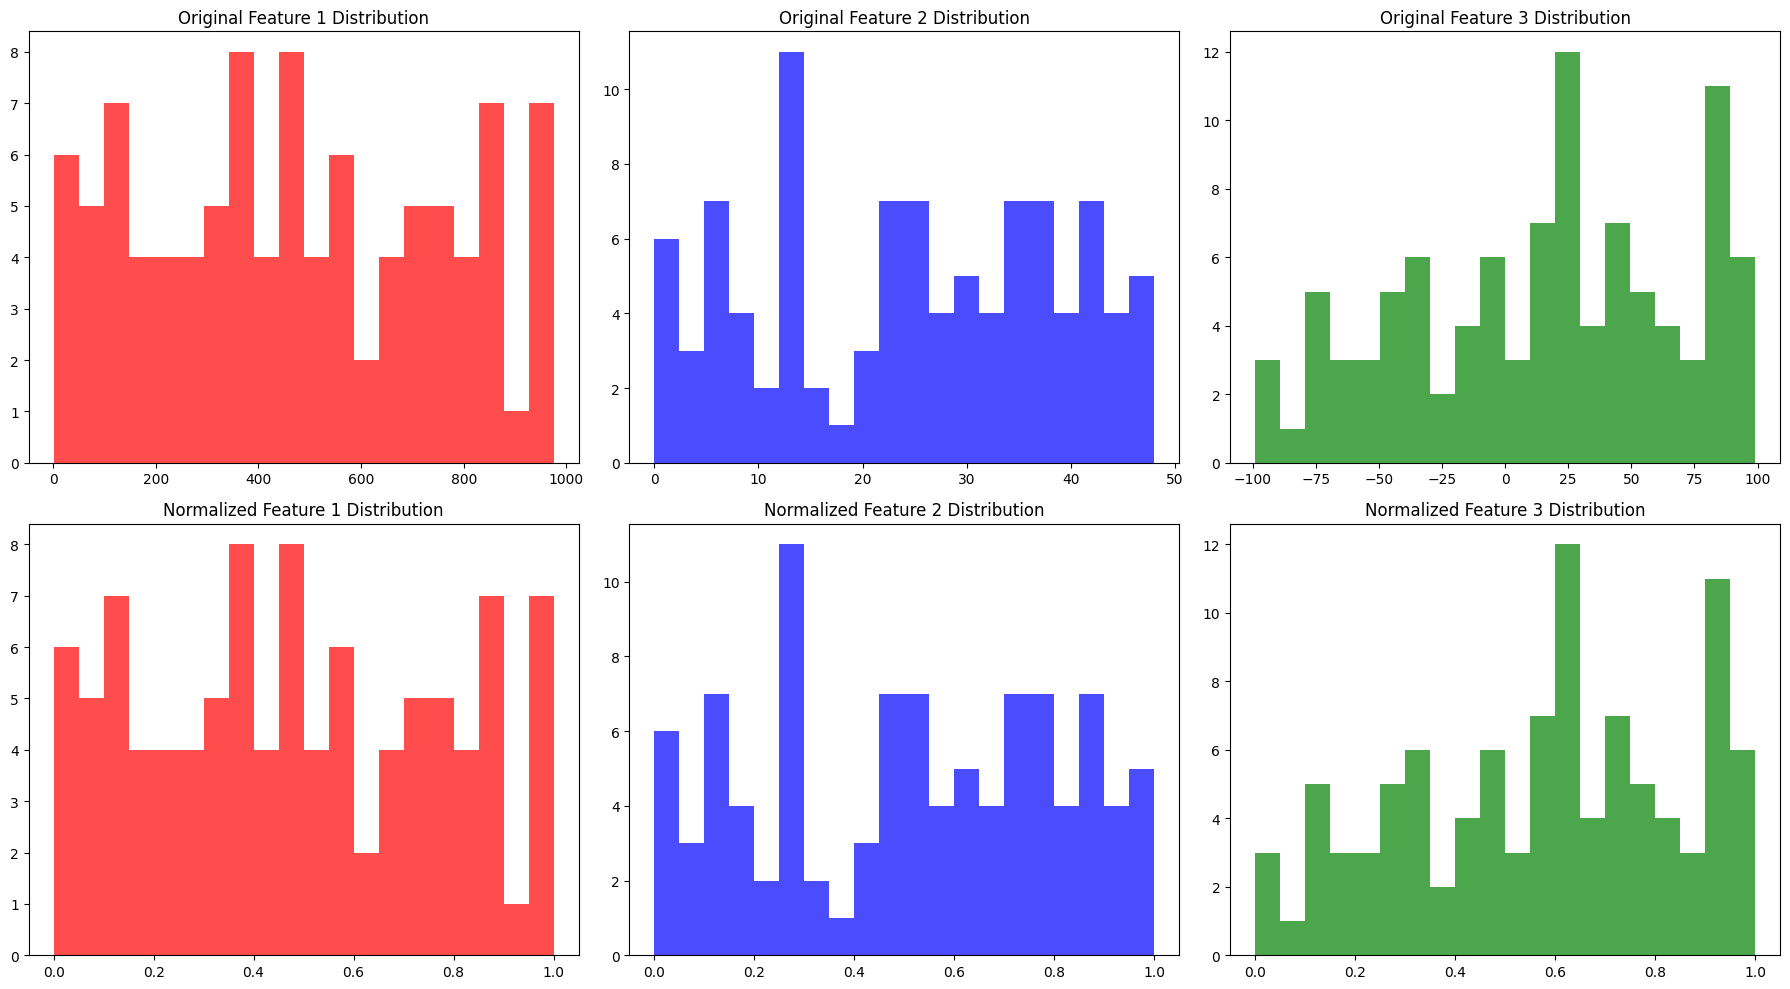

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 生成虚拟数据集
np.random.seed(42)
data = {
    'Feature 1': np.random.randint(0, 1000, 100),
    'Feature 2': np.random.randint(0, 50, 100),
    'Feature 3': np.random.randint(-100, 100, 100)
}

df = pd.DataFrame(data)

# 数据标准化
scaler = MinMaxScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# 创建绘图
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 原始数据分布
axes[0, 0].hist(df['Feature 1'], bins=20, color='red', alpha=0.7)
axes[0, 0].set_title('Original Feature 1 Distribution')
axes[0, 1].hist(df['Feature 2'], bins=20, color='blue', alpha=0.7)
axes[0, 1].set_title('Original Feature 2 Distribution')
axes[0, 2].hist(df['Feature 3'], bins=20, color='green', alpha=0.7)
axes[0, 2].set_title('Original Feature 3 Distribution')

# 标准化后数据分布
axes[1, 0].hist(df_normalized['Feature 1'], bins=20, color='red', alpha=0.7)
axes[1, 0].set_title('Normalized Feature 1 Distribution')
axes[1, 1].hist(df_normalized['Feature 2'], bins=20, color='blue', alpha=0.7)
axes[1, 1].set_title('Normalized Feature 2 Distribution')
axes[1, 2].hist(df_normalized['Feature 3'], bins=20, color='green', alpha=0.7)
axes[1, 2].set_title('Normalized Feature 3 Distribution')

# 调整布局
plt.tight_layout()
plt.show()

- 数据生成: 使用 numpy 生成三个不同范围的随机数据，模拟真实世界中具有不同尺度的特征。  
- 数据标准化: 使用 MinMaxScaler 将数据缩放到 [0, 1] 的范围内，这是一种常见的标准化方法。
- 图形绘制: 使用 matplotlib 生成 6 个子图。第一行显示原始数据的分布，第二行显示标准化后数据的分布。通过对比两行的图形，可以直观地看到标准化对数据分布的影响。


### 3. 数据编码 (Encoding)

#### 3.1 类别编码 (Label Encoding)
**原理**  
类别编码将分类特征转换为整数值，适用于有序类别。

**公式**  
假设类别变量$C = \{c_1, c_2, ..., c_k\}$，将其编码为：$Label(c_i) = i - 1$  

**推导**  
类别编码的思想是将类别标签映射为整数，通常直接根据类别的出现顺序进行编码。对于有序类别，例如评级（低、中、高），类别编码能保留顺序信息。

#### 3.2 独热编码 (One-Hot Encoding)
**原理**  
独热编码将分类变量转换为二进制向量，适用于无序类别，避免了类别编码带来的顺序问题。

**公式**  
对于类别$c_i$，独热编码如下：$OneHot(c_i) = (0, ..., 1, ..., 0)$（第$i$个位置为1，其余为0）  

**推导**  
- 独热编码通过构造与类别数量相同的二进制位来表示每个类别。假设有$k$个类别，每个类别用一个长度为$k$的二进制向量表示，且每个向量中只有一个位置为1，其余位置为0。  
- 这种编码方式能够消除类别之间的潜在顺序关系，同时将类别转换为可用于机器学习算法（如线性模型）的特征。  

**Python案例**  
这个示例使用One-Hot Encoding和Label Encoding两种编码方法，通过图形展示了编码前后的数据分布。

C:\Users\wangx.MARVIN-HOME\AppData\Local\Temp\ipykernel_4844\1277158495.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data['Category'], palette="Set2")


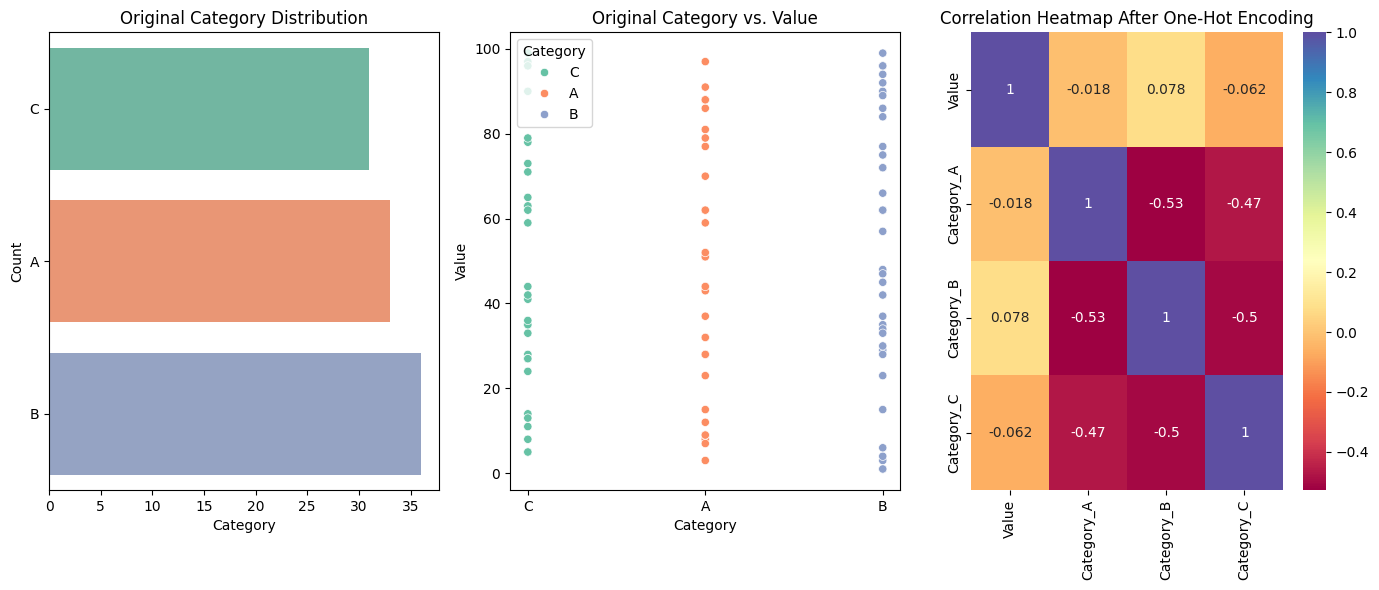

C:\Users\wangx.MARVIN-HOME\AppData\Local\Temp\ipykernel_4844\1277158495.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data['Category_Label'], palette="Set1")


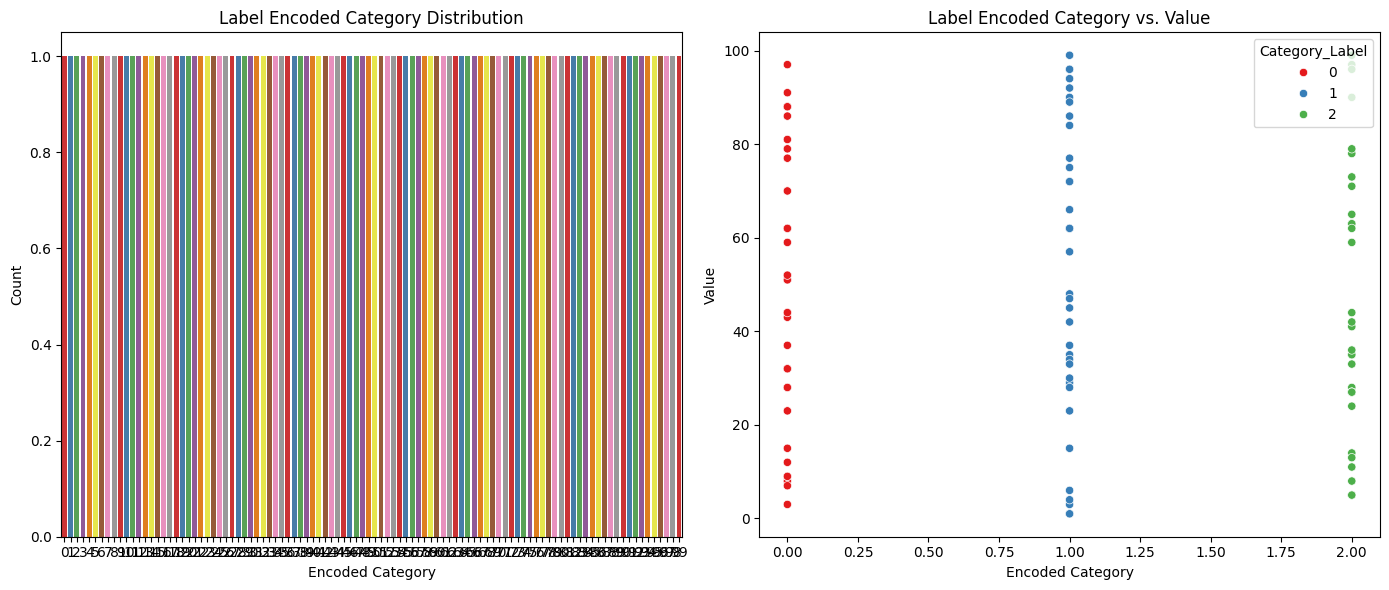

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# 生成虚拟数据集
np.random.seed(42)
data = pd.DataFrame({
    'Category': np.random.choice(['A', 'B', 'C'], 100),
    'Value': np.random.randint(1, 100, 100)
})

# 原始数据分布图
plt.figure(figsize=(14, 6))

plt.subplot(1, 3, 1)
sns.countplot(data['Category'], palette="Set2")
plt.title('Original Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
sns.scatterplot(x='Category', y='Value', data=data, palette="Set2", hue='Category')
plt.title('Original Category vs. Value')
plt.xlabel('Category')
plt.ylabel('Value')

# One-Hot Encoding
onehot_encoder = OneHotEncoder(sparse_output=False) #旧版 (sparse=False)
onehot_encoded = onehot_encoder.fit_transform(data[['Category']])
onehot_encoded_df = pd.DataFrame(onehot_encoded, columns=onehot_encoder.get_feature_names_out(['Category']))

# 将One-Hot编码后的特征加入原始数据集中
data_onehot = pd.concat([data.drop('Category', axis=1), onehot_encoded_df], axis=1)

plt.subplot(1, 3, 3)
sns.heatmap(data_onehot.corr(), annot=True, cmap="Spectral")
plt.title('Correlation Heatmap After One-Hot Encoding')

plt.tight_layout()
plt.show()

# Label Encoding
label_encoder = LabelEncoder()
data['Category_Label'] = label_encoder.fit_transform(data['Category'])

# 生成新的图表
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.countplot(data['Category_Label'], palette="Set1")
plt.title('Label Encoded Category Distribution')
plt.xlabel('Encoded Category')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.scatterplot(x='Category_Label', y='Value', data=data, hue='Category_Label', palette="Set1")
plt.title('Label Encoded Category vs. Value')
plt.xlabel('Encoded Category')
plt.ylabel('Value')

plt.tight_layout()
plt.show()

1. 虚拟数据集生成：Category列包含三个类别'A'、'B'和'C'。Value列包含从1到100之间的随机整数。  
2. One-Hot Encoding：使用OneHotEncoder对Category列进行One-Hot编码。将编码后的结果添加到原始数据集，并绘制相关性热图。  
3. Label Encoding：使用LabelEncoder将类别标签转换为数字编码。生成新的类别分布和散点图。  
- 第一组图显示了编码前和One-Hot编码后的数据特征。 
- 第二组图展示了使用Label Encoding编码后的数据分布。



### 4. 特征选择 (Feature Selection)

#### 4.1 过滤法 (Filter Method)
**原理**  
过滤法根据特征与目标变量之间的统计关系（如相关系数、卡方检验）来选择特征，通常用于数据预处理阶段。

**方法与公式**  
**相关系数**：用于衡量连续特征与目标变量之间的线性关系。皮尔逊相关系数公式如下：  
$r = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^n (x_i - \bar{x})^2} \cdot \sqrt{\sum_{i=1}^n (y_i - \bar{y})^2}}$  

**推导**  
- 皮尔逊相关系数$r$衡量两个变量$x$和$y$之间的线性相关程度。  
- 公式的分子部分是两个变量与各自均值差值的乘积之和，分母部分是这两个差值的标准差的乘积。  
- 通过标准化$x$和$y$，皮尔逊相关系数将位于[-1, 1]之间。值越接近1或-1，表示线性关系越强。

#### 4.2 包裹法 (Wrapper Method)
**原理**  
包裹法通过训练模型并使用模型性能来选择特征子集。常见方法有递归特征消除（RFE）。

**步骤与公式**  
**递归特征消除 (RFE)**  
1. 使用初始特征集训练模型，计算每个特征的重要性。  
2. 移除最不重要的特征，重新训练模型。  
3. 重复上述过程，直到选定的特征数目达到预设的目标。  

**推导**  
- 递归特征消除的思想是逐步移除对模型贡献最小的特征。通过反复训练和特征移除，最终选择最优的特征子集。  
- 这种方法计算量较大，因为需要多次训练模型，但通常能够获得比简单过滤法更好的结果。

#### 4.3 嵌入法 (Embedded Method)
**原理**  
嵌入法在模型训练过程中自动选择重要特征，常见方法如Lasso回归。

**公式**  
Lasso回归：Lasso通过加入L1正则化项来进行特征选择：  
$J(\beta) = \sum_{i=1}^n (y_i - \beta_0 - \sum_{j=1}^p \beta_j x_{ij})^2 + \lambda \sum_{j=1}^p |\beta_j|$  

**推导**  
- Lasso回归的目标是通过惩罚模型的复杂度（即权重的绝对值和）来选择重要特征。  
- 正则化项$\lambda \sum_{j=1}^p |\beta_j|$使得一些特征的权重$\beta_j$被压缩为零，从而实现特征选择。  
- Lasso的这一特性来自于L1范数的凸性和稀疏性。相比于L2范数（如Ridge回归），L1范数更倾向于产生稀疏解，即大部分权重为零的解。

**Python案例**  
应用特征选择技术来选择最相关的特征，并通过绘制相关性热图和特征重要性图来可视化数据分析的结果。


C:\Users\wangx.MARVIN-HOME\AppData\Local\Temp\ipykernel_4844\2833717077.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=selected_feature_names, palette='bright', ax=axs[1])


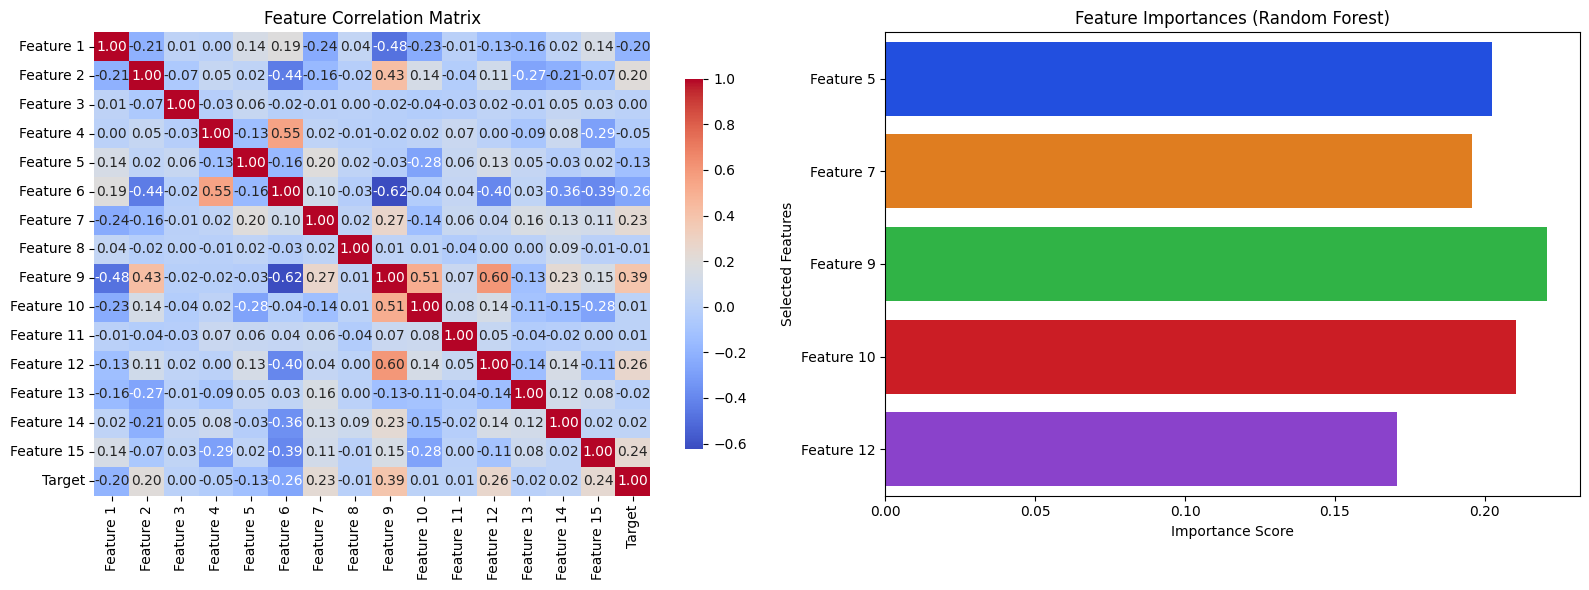

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.feature_selection import SelectKBest, f_classif

# 设置随机种子
np.random.seed(42)

# 生成虚拟数据集
X, y = make_classification(n_samples=500, n_features=15, n_informative=10, n_redundant=2, n_classes=3, random_state=42)
feature_names = [f'Feature {i+1}'for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df['Target'] = y

# 计算相关性矩阵
correlation_matrix = df.corr()

# 选择与目标变量最相关的前5个特征
selector = SelectKBest(score_func=f_classif, k=5)
selector.fit(df[feature_names], y)
selected_features = selector.get_support(indices=True)
selected_feature_names = [feature_names[i] for i in selected_features]

# 使用随机森林计算特征重要性
model = RandomForestClassifier(random_state=42)
model.fit(df[selected_feature_names], y)
importances = model.feature_importances_

# 创建子图
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# 绘制相关性热图
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axs[0], cbar_kws={'shrink': .8})
axs[0].set_title('Feature Correlation Matrix')

# 绘制特征重要性图
sns.barplot(x=importances, y=selected_feature_names, palette='bright', ax=axs[1])
axs[1].set_title('Feature Importances (Random Forest)')
axs[1].set_xlabel('Importance Score')
axs[1].set_ylabel('Selected Features')

# 显示图形
plt.tight_layout()
plt.show()

1. 生成虚拟数据集: 我们使用 make_classification 生成了一个包含500个样本和15个特征的虚拟分类数据集，其中10个特征是信息性的（有助于分类），2个是冗余的，剩下的3个是无关的噪声。  
2. 相关性矩阵: 计算了特征之间的相关性，并绘制了热图，以显示特征之间的线性关系。  
3. 特征选择: 使用 SelectKBest 方法选择了与目标变量最相关的前5个特征。  
4. 特征重要性: 通过训练随机森林分类器，计算出选定特征的重要性分数，并绘制特征重要性条形图。



### 5. 特征缩放 (Feature Scaling)

#### 5.1 标准化与归一化
标准化与归一化在前面已经详细讨论。

#### 5.2 对数变换 (Log Transformation)
**原理**  
对数变换适用于数据分布右偏的特征，通过取对数，可以减小数据的量级差异，降低极端值的影响。

**公式**  
$x' = \log(x + 1)$  

**推导**  
- 对数变换是非线性变换的一种，将数据的乘法关系转化为加法关系。  
- 当数据集中存在较大差异时，直接处理可能不利于模型的学习。通过对数变换，可以将数据的尺度压缩，从而减少大值对模型的影响。  
- 加1是为了防止数据中存在零值时取对数出现数学错误。

**Python案例**  
下面是使用虚拟数据集进行特征缩放的代码示例，包括两种不同的特征缩放方法：标准化 (Standardization)和 最小最大缩放 (Min-Max Scaling)。


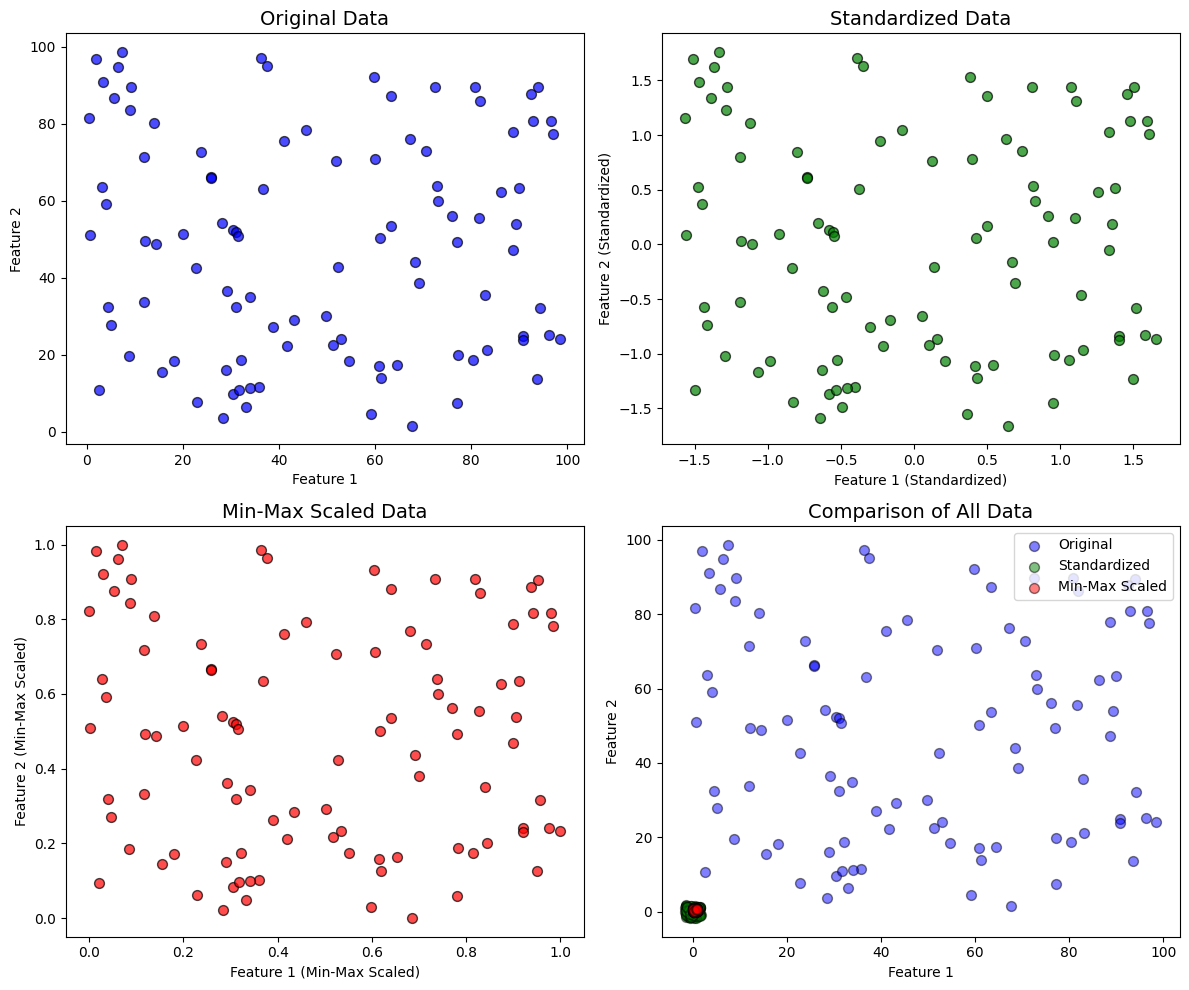

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 生成虚拟数据集
np.random.seed(42)
data = np.random.rand(100, 2) * 100# 100个样本，2个特征，范围0-100之间

# 创建标准化（Standardization）和最小最大缩放（Min-Max Scaling）对象
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

# 进行特征缩放
data_standardized = scaler_standard.fit_transform(data)
data_minmax_scaled = scaler_minmax.fit_transform(data)

# 绘图
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# 原始数据分布
axs[0, 0].scatter(data[:, 0], data[:, 1], color='blue', edgecolor='k', s=50, alpha=0.7)
axs[0, 0].set_title("Original Data", fontsize=14)
axs[0, 0].set_xlabel("Feature 1")
axs[0, 0].set_ylabel("Feature 2")

# 标准化后的数据分布
axs[0, 1].scatter(data_standardized[:, 0], data_standardized[:, 1], color='green', edgecolor='k', s=50, alpha=0.7)
axs[0, 1].set_title("Standardized Data", fontsize=14)
axs[0, 1].set_xlabel("Feature 1 (Standardized)")
axs[0, 1].set_ylabel("Feature 2 (Standardized)")

# 最小最大缩放后的数据分布
axs[1, 0].scatter(data_minmax_scaled[:, 0], data_minmax_scaled[:, 1], color='red', edgecolor='k', s=50, alpha=0.7)
axs[1, 0].set_title("Min-Max Scaled Data", fontsize=14)
axs[1, 0].set_xlabel("Feature 1 (Min-Max Scaled)")
axs[1, 0].set_ylabel("Feature 2 (Min-Max Scaled)")

# 原始数据与缩放后数据对比
axs[1, 1].scatter(data[:, 0], data[:, 1], color='blue', label='Original', edgecolor='k', s=50, alpha=0.5)
axs[1, 1].scatter(data_standardized[:, 0], data_standardized[:, 1], color='green', label='Standardized', edgecolor='k', s=50, alpha=0.5)
axs[1, 1].scatter(data_minmax_scaled[:, 0], data_minmax_scaled[:, 1], color='red', label='Min-Max Scaled', edgecolor='k', s=50, alpha=0.5)
axs[1, 1].set_title("Comparison of All Data", fontsize=14)
axs[1, 1].set_xlabel("Feature 1")
axs[1, 1].set_ylabel("Feature 2")
axs[1, 1].legend(loc='upper right')

# 调整图像布局
plt.tight_layout()
plt.show()

1. 数据生成：使用 np.random.rand 生成随机数据，数据范围在0-100之间，包含100个样本，每个样本有2个特征。  
2. 特征缩放：使用 StandardScaler 和 MinMaxScaler 进行标准化和最小最大缩放。  
- 原始数据的分布图。  
- 标准化后的数据分布图。  
- 最小最大缩放后的数据分布图。  
- 原始数据、标准化数据和最小最大缩放数据的对比图。


### 6. 降维 (Dimensionality Reduction)

#### 6.1 主成分分析 (PCA)
**原理**  
PCA是一种线性降维方法，通过主成分变换，将数据从高维空间投影到低维空间，保留尽可能多的方差信息。

**核心公式**  
$Z = X \cdot W$  
其中，$X$是中心化后的数据矩阵，$W$是主成分的权重矩阵（即特征向量矩阵），$Z$是降维后的数据。

**推导**  
1. 数据中心化：将数据矩阵$X$的每个特征减去均值，使得每列均值为0。  
2. 计算协方差矩阵：$C = \frac{1}{n-1} X^T X$  
3. 求解特征值和特征向量：对协方差矩阵求解特征值$\lambda_1 \geq \lambda_2 \geq ... \geq \lambda_d$和特征向量$w_1, w_2, ..., w_d$。  
4. 选择主成分：选择对应最大特征值的前$k$个特征向量作为主成分，形成权重矩阵$W = [w_1, w_2, ..., w_k]$。  
5. 投影数据：将原始数据投影到新空间：$Z = X \cdot W$  

**Python案例**  
下面是一个使用PCA（主成分分析）和t-SNE（t-分布随机邻域嵌入）进行降维的案例。

Exception in thread Thread-9 (_readerthread):
Traceback (most recent call last):
  File "d:\Program Files\Tools\miniconda3\envs\PyNN\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "d:\Program Files\Tools\miniconda3\envs\PyNN\Lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "d:\Program Files\Tools\miniconda3\envs\PyNN\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "d:\Program Files\Tools\miniconda3\envs\PyNN\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xce in position 4: invalid continuation byte


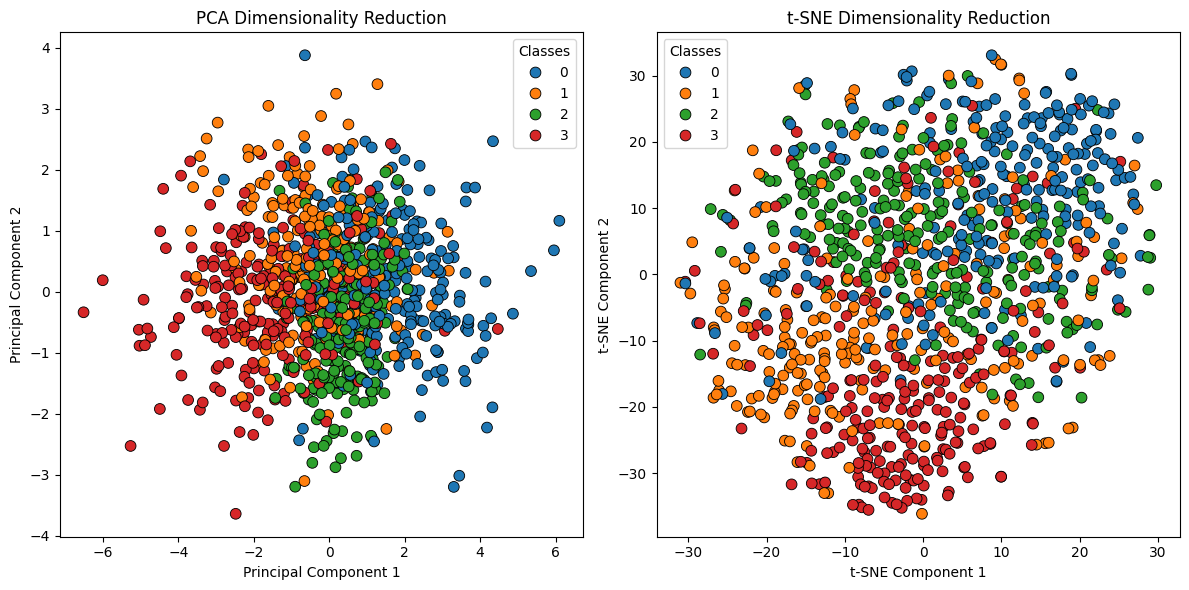

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# 生成虚拟数据集
n_samples = 1000
n_features = 20
n_classes = 4
X, y = make_classification(n_samples=n_samples, n_features=n_features, 
                           n_classes=n_classes, random_state=42, n_clusters_per_class=1)

# 标准化数据
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA降维
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# t-SNE降维
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# 绘图
plt.figure(figsize=(12, 6))

# PCA图
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='tab10', s=60, edgecolor='k')
plt.title('PCA Dimensionality Reduction')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Classes')

# t-SNE图
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='tab10', s=60, edgecolor='k')
plt.title('t-SNE Dimensionality Reduction')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(title='Classes')

plt.tight_layout()
plt.show()

1. 数据生成: 使用make_classification生成一个虚拟数据集，有20个特征和4个分类。

2. 数据标准化: 使用StandardScaler对数据进行标准化，以确保每个特征的均值为0，方差为1。

3. PCA降维: 将数据降维到2维，以便进行可视化。

4. t-SNE降维: 将数据降维到2维，用于对比PCA的效果。


### 7. 数据拆分 (Data Splitting)

#### 7.1 训练集/验证集/测试集划分
**原理**  
将数据集划分为训练集、验证集和测试集，分别用于模型训练、参数调优和性能评估。

**公式**  
数据划分比例通常为70:15:15或80:10:10。

#### 7.2 交叉验证 (Cross-Validation)
**原理**  
交叉验证通过多次划分数据集和重复训练模型，降低模型对特定数据集划分的依赖性。

**方法**  
k折交叉验证：将数据集随机划分为k个子集，每次选择其中一个子集作为验证集，剩下的作为训练集，重复k次。  

**推导**  
通过将每个样本都作为一次验证集中的样本，使得所有数据点均参与模型的训练和验证，最终的模型性能是k次实验结果的平均值。

**Python案例**

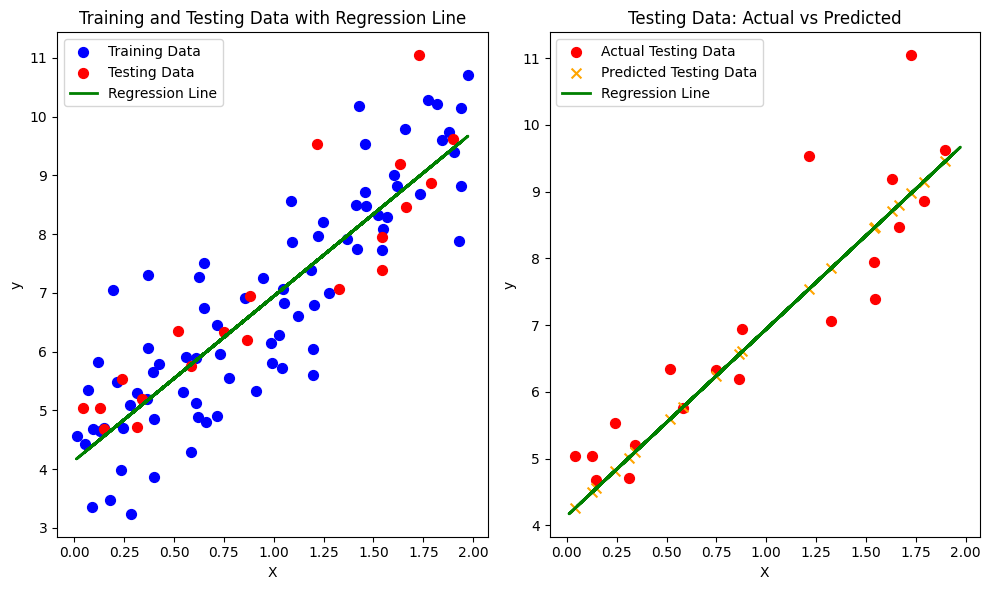

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 生成虚拟数据集
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# 数据拆分：80% 训练集，20% 测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 拟合线性回归模型
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# 在训练集和测试集上做预测
y_train_pred = lin_reg.predict(X_train)
y_test_pred = lin_reg.predict(X_test)

# 设置图形大小和颜色
plt.figure(figsize=(10, 6))

# 图1：训练集与测试集数据的散点图
plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, color='blue', label='Training Data', s=50)
plt.scatter(X_test, y_test, color='red', label='Testing Data', s=50)
plt.plot(X_train, y_train_pred, color='green', label='Regression Line', linewidth=2)
plt.title('Training and Testing Data with Regression Line', fontsize=12)
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

# 图2：测试集的预测结果与实际值对比
plt.subplot(1, 2, 2)
plt.scatter(X_test, y_test, color='red', label='Actual Testing Data', s=50)
plt.scatter(X_test, y_test_pred, color='orange', label='Predicted Testing Data', s=50, marker='x')
plt.plot(X_train, y_train_pred, color='green', label='Regression Line', linewidth=2)
plt.title('Testing Data: Actual vs Predicted', fontsize=12)
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

# 显示图形
plt.tight_layout()
plt.show()

1. 数据生成：创建了一个具有线性关系的虚拟数据集  y = 4 + 3X + {noise} ，其中 noise 是一些随机噪声。  
2. 数据拆分：使用 train_test_split 将数据集按 80% 和 20% 分别划分为训练集和测试集。  
3. 线性回归拟合：对训练集数据进行线性回归拟合，获取回归模型。  
- 图1：展示了训练集（蓝色点）、测试集（红色点）以及基于训练集的回归拟合线（绿色线）。这有助于观察模型对训练数据的拟合情况。  
- 图2：展示了测试集的实际值（红色点）和预测值（橙色叉号），并再次绘制了回归拟合线。这帮助分析模型在测试集上的预测性能。



### 8. 数据增强 (Data Augmentation)

#### 8.1 图像数据增强 (Image Data Augmentation)
**原理**  
通过旋转、缩放、裁剪等方法生成更多的图像样本，增加数据的多样性，提高模型的泛化能力。

**方法**  
常用方法包括随机裁剪、水平/垂直翻转、颜色抖动、仿射变换等。

#### 8.2 文本数据增强 (Text Data Augmentation)
**原理**  
通过同义词替换、词序交换、随机插入/删除等方法生成更多的文本样本。

**方法**  
数据增强的目的是通过生成不同的样本来增强模型的鲁棒性，并且避免过拟合。

**Python案例**  
生成一个虚拟的 2D 点数据集，并模拟对这些点进行不同方式的数据增强（旋转和翻转）。最终绘制增强前后的数据分布图，同时使用 Seaborn 进行密度分布（KDE）绘制。

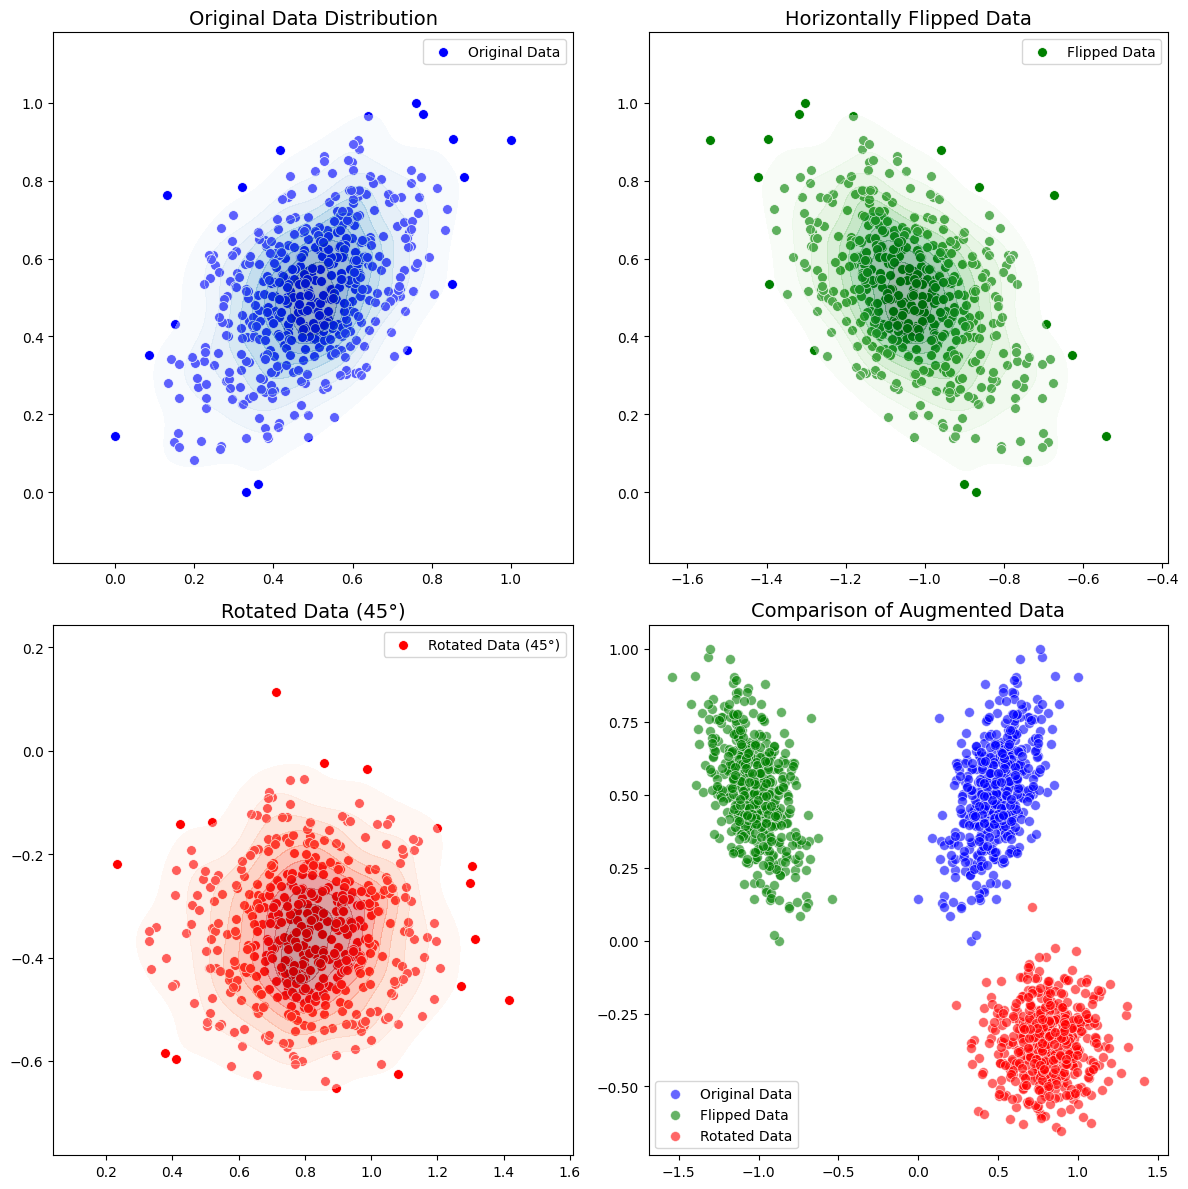

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# 设置随机种子
np.random.seed(42)

# 生成虚拟数据集：2D 正态分布
mean = [5, 5]
cov = [[1, 0.5], [0.5, 1]]  # 协方差矩阵
data = np.random.multivariate_normal(mean, cov, 500)

# 数据增强：1. 图像翻转（左右翻转）
def flip_horizontal(data):
    flipped_data = data.copy()
    flipped_data[:, 0] = -flipped_data[:, 0]  # 反转x轴
    return flipped_data

# 数据增强：2. 图像旋转（旋转角度为45度）
def rotate(data, angle_degrees):
    angle_radians = np.deg2rad(angle_degrees)
    rotation_matrix = np.array([[np.cos(angle_radians), -np.sin(angle_radians)],
                                [np.sin(angle_radians), np.cos(angle_radians)]])
    rotated_data = np.dot(data, rotation_matrix)
    return rotated_data

# 进行数据增强
flipped_data = flip_horizontal(data)
rotated_data = rotate(data, 45)

# 数据缩放到[0, 1]范围以便可视化
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)
flipped_data_scaled = scaler.transform(flip_horizontal(data))
rotated_data_scaled = scaler.transform(rotate(data, 45))

# 创建子图
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

# 原始数据分布
sns.scatterplot(x=data_scaled[:, 0], y=data_scaled[:, 1], ax=axs[0, 0], s=50, color='blue', label='Original Data')
sns.kdeplot(x=data_scaled[:, 0], y=data_scaled[:, 1], ax=axs[0, 0], cmap='Blues', fill=True, alpha=0.4)
axs[0, 0].set_title('Original Data Distribution', fontsize=14)
axs[0, 0].legend()

# 翻转后的数据分布
sns.scatterplot(x=flipped_data_scaled[:, 0], y=flipped_data_scaled[:, 1], ax=axs[0, 1], s=50, color='green', label='Flipped Data')
sns.kdeplot(x=flipped_data_scaled[:, 0], y=flipped_data_scaled[:, 1], ax=axs[0, 1], cmap='Greens', fill=True, alpha=0.4)
axs[0, 1].set_title('Horizontally Flipped Data', fontsize=14)
axs[0, 1].legend()

# 旋转后的数据分布
sns.scatterplot(x=rotated_data_scaled[:, 0], y=rotated_data_scaled[:, 1], ax=axs[1, 0], s=50, color='red', label='Rotated Data (45°)')
sns.kdeplot(x=rotated_data_scaled[:, 0], y=rotated_data_scaled[:, 1], ax=axs[1, 0], cmap='Reds', fill=True, alpha=0.4)
axs[1, 0].set_title('Rotated Data (45°)', fontsize=14)
axs[1, 0].legend()

# 三种数据的对比
sns.scatterplot(x=data_scaled[:, 0], y=data_scaled[:, 1], ax=axs[1, 1], s=50, color='blue', label='Original Data', alpha=0.6)
sns.scatterplot(x=flipped_data_scaled[:, 0], y=flipped_data_scaled[:, 1], ax=axs[1, 1], s=50, color='green', label='Flipped Data', alpha=0.6)
sns.scatterplot(x=rotated_data_scaled[:, 0], y=rotated_data_scaled[:, 1], ax=axs[1, 1], s=50, color='red', label='Rotated Data', alpha=0.6)
axs[1, 1].set_title('Comparison of Augmented Data', fontsize=14)
axs[1, 1].legend()

# 设置子图间距
plt.tight_layout()
plt.show()

1. 生成虚拟数据：生成了一个500个点的2D正态分布数据集。

2. 数据增强：

- 进行了水平翻转（左右反转 x 轴数据）。  
- 进行了45度旋转。  

- 原始数据的散点图和密度分布。
- 水平翻转后的数据的散点图和密度分布。
- 旋转后的数据的散点图和密度分布。
- 最后对比展示原始数据、翻转数据和旋转数据的散点图。

### 9. 数据平衡 (Data Balancing)

#### 9.1 欠采样 (Under-sampling)
**原理**  
通过减少多数类样本的数量，使得类别分布更加平衡。

**方法**  
随机删除多数类样本，或选择性保留代表性样本。

#### 9.2 过采样 (Over-sampling)
**原理**  
通过增加少数类样本的数量，使得类别分布更加平衡。

**方法**  
常用方法包括随机复制少数类样本、SMOTE算法（合成少数类样本）等。

**Python案例**  
使用虚拟数据集进行数据平衡的案例，针对 分类不平衡问题。在这个例子中，我们生成一个分类不平衡的数据集，随后使用 过采样 (Oversampling) 和 欠采样 (Undersampling) 方法对数据进行平衡，最后展示不同阶段的类别分布。


原始数据分布: Counter({np.float64(0.0): 900, np.float64(1.0): 100})
欠采样后数据分布: Counter({np.float64(0.0): 100, np.float64(1.0): 100})
过采样后数据分布: Counter({np.float64(0.0): 900, np.float64(1.0): 900})


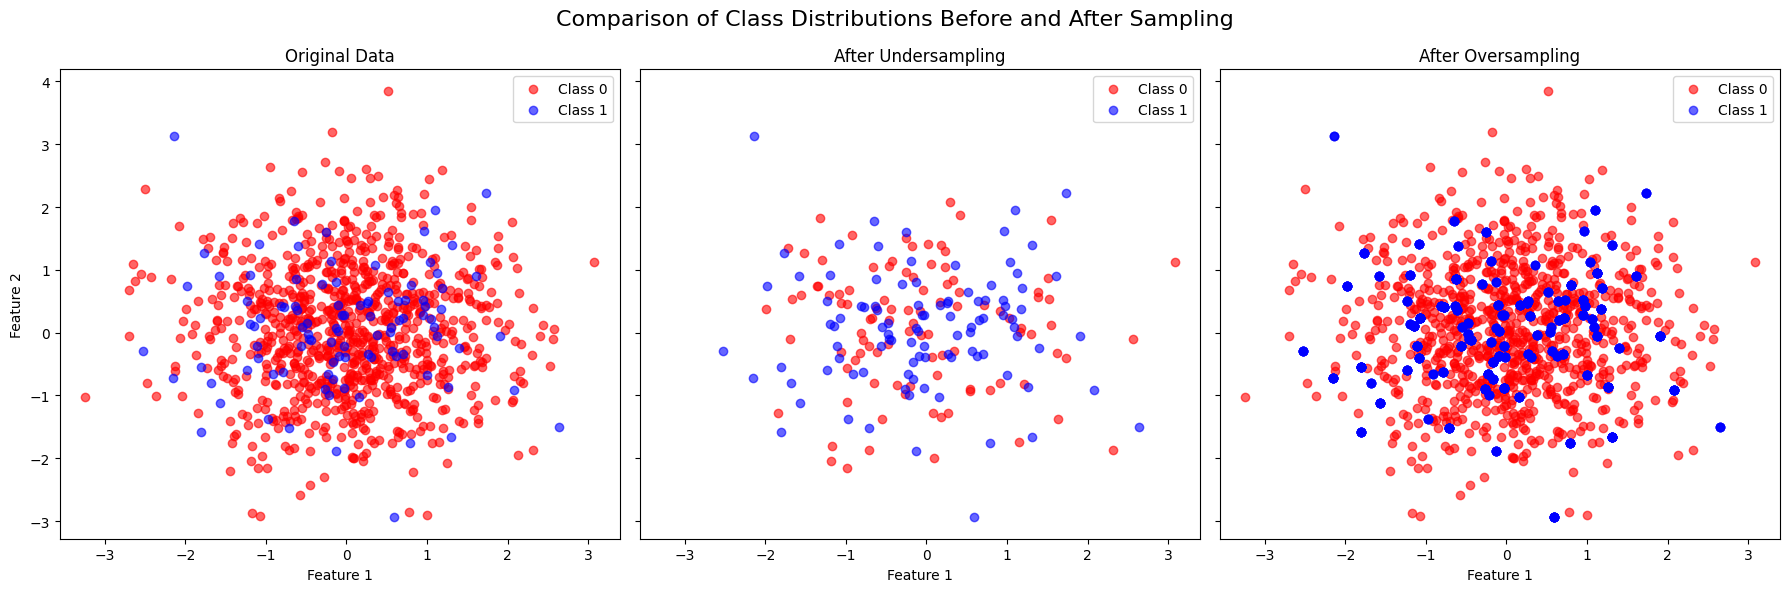

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# 设置随机种子，保证结果可重复
np.random.seed(42)

# 生成虚拟数据集 (不平衡)
# 类别 0 占 90%，类别 1 占 10%
X = np.random.randn(1000, 2)  # 两个特征
y = np.hstack([np.zeros(900), np.ones(100)])

# 打印原始数据类别分布
print("原始数据分布:", Counter(y))

# 欠采样
undersampler = RandomUnderSampler(sampling_strategy='majority', random_state=42)
X_under, y_under = undersampler.fit_resample(X, y)

# 打印欠采样后类别分布
print("欠采样后数据分布:", Counter(y_under))

# 过采样
oversampler = RandomOverSampler(sampling_strategy='minority', random_state=42)
X_over, y_over = oversampler.fit_resample(X, y)

# 打印过采样后类别分布
print("过采样后数据分布:", Counter(y_over))

# 画图 - 原始数据、欠采样后数据、过采样后数据的对比
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

# 原始数据分布
axes[0].scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0', alpha=0.6)
axes[0].scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1', alpha=0.6)
axes[0].set_title("Original Data")
axes[0].legend()
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# 欠采样后的数据分布
axes[1].scatter(X_under[y_under == 0][:, 0], X_under[y_under == 0][:, 1], color='red', label='Class 0', alpha=0.6)
axes[1].scatter(X_under[y_under == 1][:, 0], X_under[y_under == 1][:, 1], color='blue', label='Class 1', alpha=0.6)
axes[1].set_title("After Undersampling")
axes[1].legend()
axes[1].set_xlabel('Feature 1')

# 过采样后的数据分布
axes[2].scatter(X_over[y_over == 0][:, 0], X_over[y_over == 0][:, 1], color='red', label='Class 0', alpha=0.6)
axes[2].scatter(X_over[y_over == 1][:, 0], X_over[y_over == 1][:, 1], color='blue', label='Class 1', alpha=0.6)
axes[2].set_title("After Oversampling")
axes[2].legend()
axes[2].set_xlabel('Feature 1')

# 设置图形的标题和显示
plt.suptitle("Comparison of Class Distributions Before and After Sampling", fontsize=16)
plt.tight_layout()
plt.show()

1. 数据生成：使用 np.random.randn 生成了1000个样本，类别0和类别1的比例分别是90%和10%，表示数据集不平衡。

2. 欠采样 (Undersampling)：使用 RandomUnderSampler 对类别0进行欠采样，使得类别0和类别1样本数量相等。

3. 过采样 (Oversampling)：使用 RandomOverSampler 对类别1进行过采样，使得类别0和类别1样本数量相等。


### 10. 数据转换 (Data Transformation)

#### 10.1 特征构造 (Feature Engineering)
**原理**  
基于现有特征组合、变换、提取新的特征，以增强模型的表达能力。

**方法**  
特征组合、离散化、交互特征、时间特征提取等。

#### 10.2 非线性变换
**原理**  
通过平方、平方根、对数等操作处理特征与标签之间的非线性关系。

**方法与公式**  
对于非线性关系，非线性变换能够提升模型拟合能力。

**Python案例**  
案例展示了标准化（Standardization）和归一化（Normalization）两种常见的数据转换方法，并分别绘制出转换前和转换后的数据分布图。虚拟数据集将使用正态分布生成。

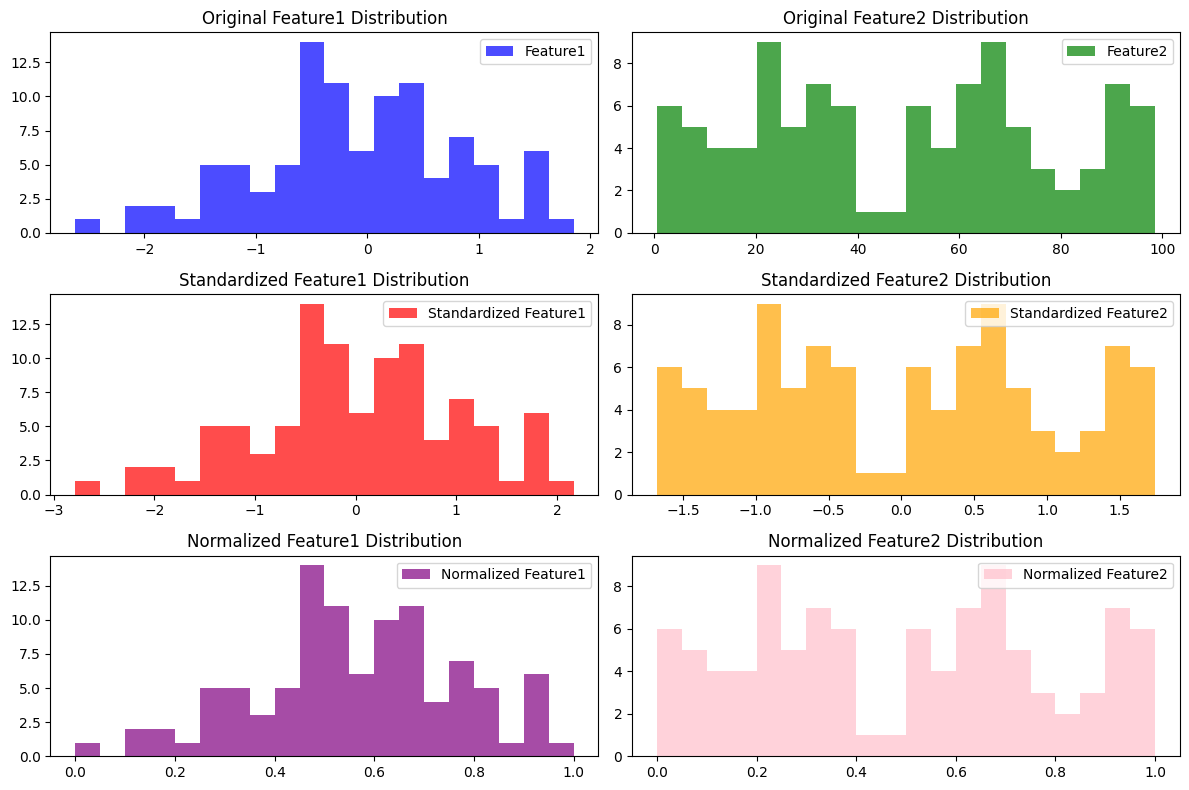

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 生成虚拟数据集
np.random.seed(42)
data = pd.DataFrame({
    'Feature1': np.random.normal(loc=0, scale=1, size=100),  # 正态分布数据
    'Feature2': np.random.rand(100) * 100# 随机生成 [0, 100] 区间数据
})

# 创建标准化和归一化的转换器
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

# 对数据进行标准化
data_standardized = scaler_standard.fit_transform(data)
data_standardized = pd.DataFrame(data_standardized, columns=data.columns)

# 对数据进行归一化
data_normalized = scaler_minmax.fit_transform(data)
data_normalized = pd.DataFrame(data_normalized, columns=data.columns)

# 绘图设置
plt.figure(figsize=(12, 8))

# 原始数据分布
plt.subplot(3, 2, 1)
plt.hist(data['Feature1'], bins=20, color='blue', alpha=0.7, label='Feature1')
plt.title('Original Feature1 Distribution', fontsize=12)
plt.legend()

plt.subplot(3, 2, 2)
plt.hist(data['Feature2'], bins=20, color='green', alpha=0.7, label='Feature2')
plt.title('Original Feature2 Distribution', fontsize=12)
plt.legend()

# 标准化后数据分布
plt.subplot(3, 2, 3)
plt.hist(data_standardized['Feature1'], bins=20, color='red', alpha=0.7, label='Standardized Feature1')
plt.title('Standardized Feature1 Distribution', fontsize=12)
plt.legend()

plt.subplot(3, 2, 4)
plt.hist(data_standardized['Feature2'], bins=20, color='orange', alpha=0.7, label='Standardized Feature2')
plt.title('Standardized Feature2 Distribution', fontsize=12)
plt.legend()

# 归一化后数据分布
plt.subplot(3, 2, 5)
plt.hist(data_normalized['Feature1'], bins=20, color='purple', alpha=0.7, label='Normalized Feature1')
plt.title('Normalized Feature1 Distribution', fontsize=12)
plt.legend()

plt.subplot(3, 2, 6)
plt.hist(data_normalized['Feature2'], bins=20, color='pink', alpha=0.7, label='Normalized Feature2')
plt.title('Normalized Feature2 Distribution', fontsize=12)
plt.legend()

# 调整布局
plt.tight_layout()
plt.show()

1. 虚拟数据集生成：Feature1 是一个正态分布的数据，而 Feature2 是在 [0, 100] 之间的均匀随机分布数据。  
2. 标准化与归一化：标准化：使用 StandardScaler 将数据转化为均值为0，标准差为1的分布。归一化：使用 MinMaxScaler 将数据映射到 [0, 1] 范围内。  
- 原始数据的分布图（Feature1 和 Feature2）
- 标准化后的数据分布图
- 归一化后的数据分布图